In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pandas.api.types import CategoricalDtype
import scipy.stats as st
from pandas import Timestamp
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

In [25]:
df1 = pd.read_csv('df_final_web_data_clean')
df2 = pd.read_csv('df_final_experiment_clients_cleaned')
df3 = pd.read_csv('df_final_demo_cleaned')
merged_df = pd.merge(df1, df2, on="client_id", how="inner")

# Then merge the result with df3
merged_df = pd.merge(merged_df, df3, on="client_id", how="inner")

In [26]:
merged_df = merged_df.drop(columns=['Unnamed: 0_x','Unnamed: 0_y','Unnamed: 0.1','Unnamed: 0'])
df = merged_df

In [50]:
df

,client_id,visitor_id,visit_id,process_step,date_time,variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,age_group,step_index,prev_step_index,prev_step,step_back,step_same,transition
186868,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17,Test,4,56,59.5,U,2,63130.44,6,9,55-64,4,NaN,NaN,False,False,NaN
186867,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:23:09,Test,4,56,59.5,U,2,63130.44,6,9,55-64,4,4.0,confirm,False,True,confirm ← confirm
316543,7338123,612065484_94198474375,100019538_17884295066_43909,start,2017-04-09 16:20:56,Test,7,88,23.5,M,2,26436.73,6,9,<25,0,NaN,NaN,False,False,NaN
316542,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:12,Test,7,88,23.5,M,2,26436.73,6,9,<25,1,0.0,start,False,False,step_1 ← start
316541,7338123,612065484_94198474375,100019538_17884295066_43909,step_2,2017-04-09 16:21:21,Test,7,88,23.5,M,2,26436.73,6,9,<25,2,1.0,step_1,False,False,step_2 ← step_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175665,6627522,730634087_44272418812,999988789_76411676596_272843,start,2017-04-21 23:49:11,Test,18,227,58.0,F,2,1056775.54,6,9,55-64,0,NaN,NaN,False,False,NaN
175664,6627522,730634087_44272418812,999988789_76411676596_272843,step_1,2017-04-21 23:49:22,Test,18,227,58.0,F,2,1056775.54,6,9,55-64,1,0.0,start,False,False,step_1 ← start
175663,6627522,730634087_44272418812,999988789_76411676596_272843,step_2,2017-04-21 23:50:16,Test,18,227,58.0,F,2,1056775.54,6,9,55-64,2,1.0,step_1,False,False,step_2 ← step_1
175662,6627522,730634087_44272418812,999988789_76411676596_272843,step_1,2017-04-21 23:51:00,Test,18,227,58.0,F,2,1056775.54,6,9,55-64,1,2.0,step_2,True,False,step_1 ← step_2


# Completion rate

In [28]:
# Step definitions
required_steps = ["start", "step_1", "step_2", "step_3", "confirm"]

# Helper: format timedelta as MM:SS
def format_minutes_seconds(td):
    if pd.isna(td):
        return "-"
    total_seconds = td.total_seconds()
    minutes = int(total_seconds // 60)
    seconds = int(total_seconds % 60)
    return f"{minutes:02d}:{seconds:02d}"

# Clean original dataframe
df_clean = df[df["process_step"].isin(required_steps)].copy()
df_clean["process_step"] = df_clean["process_step"].str.strip().str.lower()
df_clean["date_time"] = pd.to_datetime(df_clean["date_time"], errors="coerce")

results = []

for variation in ["Control", "Test"]:
    df_var = df_clean[df_clean["variation"] == variation]

    # Get earliest timestamp per step per visit
    df_first = (
        df_var.sort_values(["visit_id", "process_step", "date_time"])
              .groupby(["visit_id", "process_step"], as_index=False)
              .first()
    )

    # Pivot: one row per visit_id, one column per step
    df_wide = df_first.pivot(index="visit_id", columns="process_step", values="date_time")
    df_wide = df_wide.reindex(columns=required_steps)

    # Completion logic
    has_all_steps = df_wide.notna().all(axis=1)
    diffs = df_wide.diff(axis=1).iloc[:, 1:]
    strictly_in_order = diffs.gt(pd.Timedelta(0)).all(axis=1)
    df_wide["is_complete"] = has_all_steps & strictly_in_order

    # Total duration
    df_wide["start_time"] = df_wide["start"]
    df_wide["end_time"] = df_wide["confirm"]
    df_wide["duration"] = df_wide["end_time"] - df_wide["start_time"]

    # Summarize
    total_started = df_wide["start"].notna().sum()
    total_completed = df_wide["is_complete"].sum()
    avg_duration = df_wide.loc[df_wide["is_complete"], "duration"].mean()

    results.append({
        "variation": variation,
        "started": total_started,
        "completed": total_completed,
        "conversion_rate": round(total_completed / total_started * 100, 2),
        "avg_duration": format_minutes_seconds(avg_duration)
    })

# Output summary table
comparison_df = pd.DataFrame(results)
print(comparison_df)

  variation  started  completed  conversion_rate avg_duration
0   Control    30905      14759            47.76        06:29
1      Test    33144      17784            53.66        06:14


C:\Users\jorgi\AppData\Local\Temp\ipykernel_2760\4211058455.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x="variation", y="conversion_rate", palette="Set2")


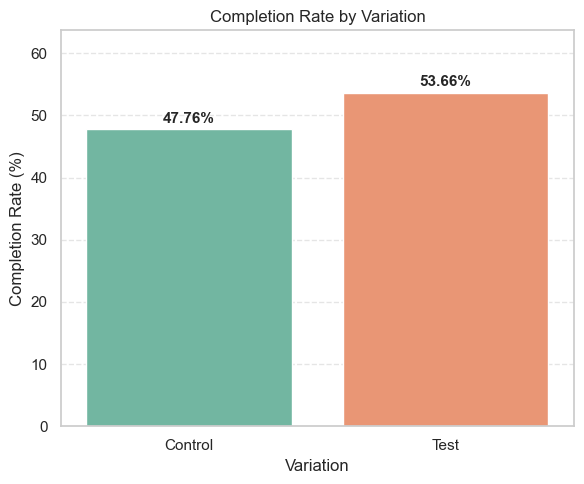


=== Z-Test for Completion Rate ===
Z-statistic: 14.9264
P-value: 0.0000
Statistically Significant?  ✅ Yes


In [29]:
# Add conversion rate
comparison_df["conversion_rate"] = comparison_df["completed"] / comparison_df["started"] * 100

# === 1. Plot Completion Rate ===
plt.figure(figsize=(6, 5))
sns.barplot(data=comparison_df, x="variation", y="conversion_rate", palette="Set2")

for i, row in comparison_df.iterrows():
    plt.text(i, row["conversion_rate"] + 0.5, f"{row['conversion_rate']:.2f}%", 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title("Completion Rate by Variation")
plt.ylabel("Completion Rate (%)")
plt.xlabel("Variation")
plt.ylim(0, comparison_df["conversion_rate"].max() + 10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# === 2. Z-Test for proportions (completion rate) ===
count = comparison_df.loc[comparison_df['variation'] == 'Test', 'completed'].tolist() + \
        comparison_df.loc[comparison_df['variation'] == 'Control', 'completed'].tolist()

nobs = comparison_df.loc[comparison_df['variation'] == 'Test', 'started'].tolist() + \
       comparison_df.loc[comparison_df['variation'] == 'Control', 'started'].tolist()
z_stat, p_val = proportions_ztest(count, nobs, alternative='larger')

# === Print Results ===
print("\n=== Z-Test for Completion Rate ===")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_val:.4f}")
print("Statistically Significant? ", "✅ Yes" if p_val < 0.05 else "❌ No")

In [30]:
df_wide

process_step,start,step_1,step_2,step_3,confirm,is_complete,start_time,end_time,duration
visit_id,,,,,,,,,
100012776_37918976071_457913,NaT,NaT,NaT,NaT,2017-04-26 13:22:17,False,NaT,2017-04-26 13:22:17,NaT
100019538_17884295066_43909,2017-04-09 16:20:56,2017-04-09 16:21:12,2017-04-09 16:21:21,2017-04-09 16:24:01,2017-04-09 16:24:58,True,2017-04-09 16:20:56,2017-04-09 16:24:58,0 days 00:04:02
100022086_87870757897_149620,2017-05-23 20:44:01,2017-05-23 20:44:23,2017-05-23 20:45:08,2017-05-23 20:46:01,2017-05-23 20:47:01,True,2017-05-23 20:44:01,2017-05-23 20:47:01,0 days 00:03:00
100173292_91322748906_143563,2017-04-25 10:28:55,2017-04-25 10:29:06,2017-04-25 10:29:14,2017-04-25 10:30:02,2017-04-25 10:30:30,True,2017-04-25 10:28:55,2017-04-25 10:30:30,0 days 00:01:35
100217156_67053490690_383412,2017-04-12 11:51:12,2017-04-12 11:51:48,2017-04-12 11:57:21,2017-04-12 11:57:59,2017-04-12 12:08:09,True,2017-04-12 11:51:12,2017-04-12 12:08:09,0 days 00:16:57
...,...,...,...,...,...,...,...,...,...
999960019_60838685252_926860,2017-04-19 18:59:22,2017-04-19 19:11:27,2017-04-19 19:23:07,NaT,NaT,False,2017-04-19 18:59:22,NaT,NaT
999971096_28827267783_236076,2017-04-13 10:31:49,2017-04-13 10:32:07,2017-04-13 10:32:53,2017-04-13 10:33:40,2017-04-13 10:34:08,True,2017-04-13 10:31:49,2017-04-13 10:34:08,0 days 00:02:19
999976049_95772503197_182554,2017-04-04 12:50:10,2017-04-04 12:52:26,2017-04-04 12:53:01,2017-04-04 12:54:54,2017-04-04 13:02:18,True,2017-04-04 12:50:10,2017-04-04 13:02:18,0 days 00:12:08


In [77]:
# === 1. Setup ===
required_steps = ["start", "step_1", "step_2", "step_3", "confirm"]
step_order = {step: i for i, step in enumerate(required_steps)}

# === 2. Filter & prepare ===
df_filtered = df[df["process_step"].isin(required_steps)].copy()
df_filtered["step_index"] = df_filtered["process_step"].map(step_order)
df_filtered["date_time"] = pd.to_datetime(df_filtered["date_time"], errors="coerce")

# === 3. Detect step-backs per visit ===
df_filtered = df_filtered.sort_values(["visit_id", "date_time"])
df_filtered["prev_step_index"] = df_filtered.groupby("visit_id")["step_index"].shift(1)
df_filtered["step_back"] = df_filtered["step_index"] < df_filtered["prev_step_index"]

# === 4. Check who completed all steps in correct order ===
# Get earliest timestamp per step per visit
df_first = df_filtered.sort_values(["visit_id", "step_index", "date_time"]) \
                      .groupby(["visit_id", "process_step"], as_index=False).first()

# Pivot to wide format
df_wide = df_first.pivot(index="visit_id", columns="process_step", values="date_time")
df_wide = df_wide[required_steps]

# Define who completed all steps in order
has_all_steps = df_wide.notna().all(axis=1)
diffs = df_wide.diff(axis=1).iloc[:, 1:]
strict_order = diffs.gt(pd.Timedelta(0)).all(axis=1)
df_wide["complete_without_errors"] = has_all_steps & strict_order

# === 5. Merge variation info ===
visit_variation = df_filtered[["visit_id", "variation"]].drop_duplicates()
df_wide = df_wide.merge(visit_variation, on="visit_id", how="left")

# === 6. Count results ===
result = df_wide.groupby("variation")["complete_without_errors"].sum().reset_index()
result.columns = ["variation", "completed_without_errors"]

print("=== ✅ Users Who Completed Without Errors ===")
print(result)

=== ✅ Users Who Completed Without Errors ===
  variation  completed_without_errors
0   Control                     14769
1      Test                     17787


In [78]:
from statsmodels.stats.proportion import proportions_ztest

# Get counts
complete_counts = df_wide.groupby("variation")["complete_without_errors"].sum()
total_counts = df_wide.groupby("variation")["visit_id"].count()

# Arrange for test
count = complete_counts.values  # [Control_completed, Test_completed]
nobs = total_counts.values      # [Control_total, Test_total]

# Run z-test
z_stat, p_val = proportions_ztest(count, nobs, alternative='two-sided')

print("\n=== 📊 Z-Test: Completion Without Errors ===")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_val:.4f}")
print("Significant?" , "✅ Yes" if p_val < 0.05 else "❌ No")


=== 📊 Z-Test: Completion Without Errors ===
Z-statistic: -5.3253
P-value: 0.0000
Significant? ✅ Yes


=== T-Test: Avg. Step-Backs per User ===
T-statistic: -9.9537
P-value: 0.0000
Significant? ✅ Yes


# Time spent by steps

In [31]:
# Step flow
required_steps = ["start", "step_1", "step_2", "step_3", "confirm"]
step_pairs = list(zip(required_steps[:-1], required_steps[1:]))

# Format helper: seconds → MM:SS
def format_minutes_seconds(seconds):
    if pd.isna(seconds):
        return "-"
    minutes = int(seconds // 60)
    secs = int(seconds % 60)
    return f"{minutes:02d}:{secs:02d}"

# Clean base dataframe
df_clean = df[df["process_step"].isin(required_steps)].copy()
df_clean["process_step"] = df_clean["process_step"].str.strip().str.lower()
df_clean["date_time"] = pd.to_datetime(df_clean["date_time"], errors="coerce")

# Store results
results = []

for variation in ["Control", "Test"]:
    df_var = df_clean[df_clean["variation"] == variation]

    # Get first timestamp per step in each visit
    df_first = (
        df_var.sort_values(["visit_id", "process_step", "date_time"])
              .groupby(["visit_id", "process_step"], as_index=False)
              .first()
    )

    # Pivot to wide format
    df_wide = df_first.pivot(index="visit_id", columns="process_step", values="date_time")
    df_wide = df_wide.reindex(columns=required_steps)

    # For each transition, compute time only where both steps exist
    avg_row = {"variation": variation}
    for step_from, step_to in step_pairs:
        col = f"{step_from} → {step_to}"
        mask = df_wide[step_from].notna() & df_wide[step_to].notna()
        durations = df_wide.loc[mask, step_to] - df_wide.loc[mask, step_from]
        mean_seconds = durations.dt.total_seconds().mean()
        avg_row[col] = format_minutes_seconds(mean_seconds)

    results.append(avg_row)

# Final dataframe
avg_step_times = pd.DataFrame(results)

# Show result
pd.set_option("display.max_columns", None)
print(avg_step_times)

  variation start → step_1 step_1 → step_2 step_2 → step_3 step_3 → confirm
0   Control          01:03           00:50           01:49            02:48
1      Test          00:51           01:15           01:47            02:22



=== Step Duration Comparison (with T-test) ===
Variation         Control    Test  T-stat  P-value  Significant (p < 0.05)
Step                                                                      
start → step_1      63.67   51.48   4.989   0.0000                    True
step_1 → step_2     50.15   75.55 -17.323   0.0000                    True
step_2 → step_3    109.57  107.47   1.248   0.2122                   False
step_3 → confirm   168.49  142.88   8.206   0.0000                    True


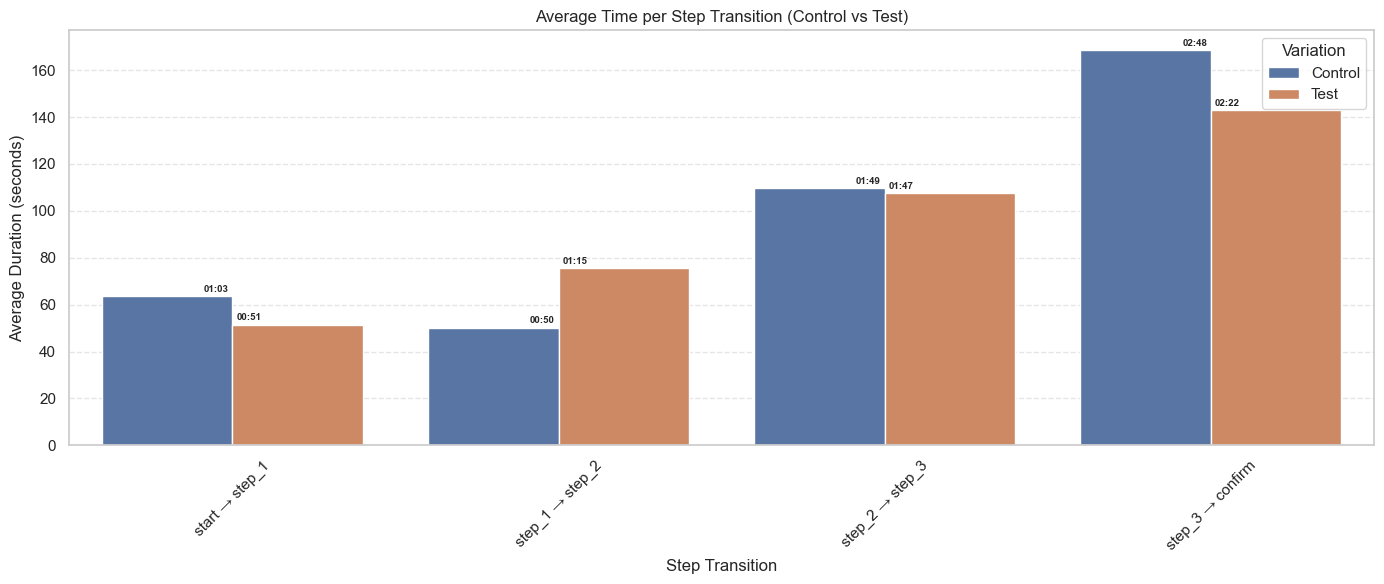

In [32]:
# Step flow
required_steps = ["start", "step_1", "step_2", "step_3", "confirm"]
step_pairs = list(zip(required_steps[:-1], required_steps[1:]))

# Format helper: seconds → MM:SS
def format_minutes_seconds(seconds):
    if pd.isna(seconds):
        return "-"
    minutes = int(seconds // 60)
    secs = int(seconds % 60)
    return f"{minutes:02d}:{secs:02d}"

# Clean base dataframe
df_clean = df[df["process_step"].isin(required_steps)].copy()
df_clean["process_step"] = df_clean["process_step"].str.strip().str.lower()
df_clean["date_time"] = pd.to_datetime(df_clean["date_time"], errors="coerce")

# Results for t-test and plot
ttest_results = []

for step_from, step_to in step_pairs:
    step_name = f"{step_from} → {step_to}"

    # Get durations for Control
    df_c = df_clean[df_clean["variation"] == "Control"]
    df_c_first = df_c.sort_values(["visit_id", "process_step", "date_time"]).groupby(["visit_id", "process_step"], as_index=False).first()
    df_c_wide = df_c_first.pivot(index="visit_id", columns="process_step", values="date_time").reindex(columns=required_steps)
    mask_c = df_c_wide[step_from].notna() & df_c_wide[step_to].notna()
    durations_c = (df_c_wide.loc[mask_c, step_to] - df_c_wide.loc[mask_c, step_from]).dt.total_seconds()

    # Get durations for Test
    df_t = df_clean[df_clean["variation"] == "Test"]
    df_t_first = df_t.sort_values(["visit_id", "process_step", "date_time"]).groupby(["visit_id", "process_step"], as_index=False).first()
    df_t_wide = df_t_first.pivot(index="visit_id", columns="process_step", values="date_time").reindex(columns=required_steps)
    mask_t = df_t_wide[step_from].notna() & df_t_wide[step_to].notna()
    durations_t = (df_t_wide.loc[mask_t, step_to] - df_t_wide.loc[mask_t, step_from]).dt.total_seconds()

    # T-test
    t_stat, p_val = ttest_ind(durations_c, durations_t, equal_var=False, nan_policy='omit')

    ttest_results.append({
        "Step": step_name,
        "Variation": "Control",
        "Avg Time (s)": durations_c.mean(),
        "Formatted": format_minutes_seconds(durations_c.mean()),
        "T-stat": t_stat,
        "P-value": p_val
    })
    ttest_results.append({
        "Step": step_name,
        "Variation": "Test",
        "Avg Time (s)": durations_t.mean(),
        "Formatted": format_minutes_seconds(durations_t.mean()),
        "T-stat": t_stat,
        "P-value": p_val
    })

# Convert to DataFrame
ttest_df = pd.DataFrame(ttest_results)

# Print summary table
summary = ttest_df.pivot(index="Step", columns="Variation", values="Avg Time (s)").round(2)
summary["T-stat"] = ttest_df.groupby("Step")["T-stat"].first().round(3)
summary["P-value"] = ttest_df.groupby("Step")["P-value"].first().round(4)
summary["Significant (p < 0.05)"] = summary["P-value"] < 0.05

print("\n=== Step Duration Comparison (with T-test) ===")
print(summary)

# === Plot: Avg Time Per Step (Bar Chart)
plt.figure(figsize=(14, 6))
sns.barplot(data=ttest_df, x="Step", y="Avg Time (s)", hue="Variation")

# Add labels
for i, row in ttest_df.iterrows():
    plt.text(x=i//2 + 0.05*(1 if row["Variation"]=="Test" else -1), 
             y=row["Avg Time (s)"] + 1, 
             s=format_minutes_seconds(row["Avg Time (s)"]),
             ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.title("Average Time per Step Transition (Control vs Test)")
plt.ylabel("Average Duration (seconds)")
plt.xlabel("Step Transition")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Variation")
plt.tight_layout()
plt.show()

# Error rate


In [33]:
# Define the steps
required_steps = ["start", "step_1", "step_2", "step_3", "confirm"]
step_pairs = list(zip(required_steps[:-1], required_steps[1:]))

# Clean and normalize
df_clean = df[df["process_step"].isin(required_steps)].copy()
df_clean["process_step"] = df_clean["process_step"].str.strip().str.lower()
df_clean["date_time"] = pd.to_datetime(df_clean["date_time"], errors="coerce")

# Results per variation
error_rate_results = []

for variation in ["Control", "Test"]:
    df_var = df_clean[df_clean["variation"] == variation]

    # Keep first timestamp per (visit_id, step)
    df_first = (
        df_var.sort_values(["visit_id", "process_step", "date_time"])
              .groupby(["visit_id", "process_step"], as_index=False)
              .first()
    )

    # Pivot: one row per visit
    df_wide = df_first.pivot(index="visit_id", columns="process_step", values="date_time")
    df_wide = df_wide.reindex(columns=required_steps)

    # Calculate number of visits reaching each step
    step_counts = df_wide.notna().sum()

    # Calculate error rate per step transition
    step_errors = {"variation": variation}
    for i in range(1, len(required_steps)):
        prev_step = required_steps[i - 1]
        curr_step = required_steps[i]

        visits_prev = step_counts[prev_step]
        visits_curr = step_counts[curr_step]

        error_rate = 1 - (visits_curr / visits_prev) if visits_prev > 0 else None
        step_errors[f"{prev_step} → {curr_step}"] = round(error_rate * 100, 2) if error_rate is not None else "-"

    error_rate_results.append(step_errors)

# Final dataframe
step_error_df = pd.DataFrame(error_rate_results)

# Show it
print("=== Step-by-Step Error Rates (%) ===")
print(step_error_df)

=== Step-by-Step Error Rates (%) ===
  variation  start → step_1  step_1 → step_2  step_2 → step_3  \
0   Control           23.82            14.48             9.13   
1      Test           14.69            13.37             9.44   

   step_3 → confirm  
0             12.33  
1              2.05  


In [34]:


# Define the process steps
required_steps = ["start", "step_1", "step_2", "step_3", "confirm"]
step_pairs = list(zip(required_steps[:-1], required_steps[1:]))

# Clean and normalize
df_clean = df[df["process_step"].isin(required_steps)].copy()
df_clean["process_step"] = df_clean["process_step"].str.strip().str.lower()
df_clean["date_time"] = pd.to_datetime(df_clean["date_time"], errors="coerce")

# Store error counts
error_count_results = []

for variation in ["Control", "Test"]:
    df_var = df_clean[df_clean["variation"] == variation]

    # Get earliest timestamp per (visit_id, step)
    df_first = (
        df_var.sort_values(["visit_id", "process_step", "date_time"])
              .groupby(["visit_id", "process_step"], as_index=False)
              .first()
    )

    # Pivot: one row per visit
    df_wide = df_first.pivot(index="visit_id", columns="process_step", values="date_time")
    df_wide = df_wide.reindex(columns=required_steps)

    # Count visits that reached each step
    step_counts = df_wide.notna().sum()

    # Calculate error counts (drop-offs) between steps
    step_errors = {"variation": variation}
    for i in range(1, len(required_steps)):
        prev_step = required_steps[i - 1]
        curr_step = required_steps[i]

        visits_prev = step_counts[prev_step]
        visits_curr = step_counts[curr_step]

        error_count = visits_prev - visits_curr
        step_errors[f"{prev_step} → {curr_step}"] = error_count

    error_count_results.append(step_errors)

# Final dataframe
step_error_counts_df = pd.DataFrame(error_count_results)

# Display
print("=== Step-by-Step Drop-off Counts ===")
print(step_error_counts_df)


=== Step-by-Step Drop-off Counts ===
  variation  start → step_1  step_1 → step_2  step_2 → step_3  \
0   Control            7362             3410             1838   
1      Test            4870             3781             2313   

   step_3 → confirm  
0              2255  
1               455  


In [35]:
step_error_df

,variation,start → step_1,step_1 → step_2,step_2 → step_3,step_3 → confirm
0,Control,23.82,14.48,9.13,12.33
1,Test,14.69,13.37,9.44,2.05


In [36]:
# Test for completion rate difference 

In [37]:
from statsmodels.stats.proportion import proportions_ztest

# Filter the correct rows first
control_row = comparison_df[comparison_df["variation"] == "Control"].iloc[0]
test_row    = comparison_df[comparison_df["variation"] == "Test"].iloc[0]

# Then extract scalar values (not Series!)
n_C = int(control_row["started"])
x_C = int(control_row["completed"])

n_T = int(test_row["started"])
x_T = int(test_row["completed"])

# Data
counts = [x_T, x_C]
nobs = [n_T, n_C]

# Perform one-tailed z-test (H1: p_T > p_C)
z_stat, p_value = proportions_ztest(count=counts, nobs=nobs, alternative='larger')

print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.4f}")

# Interpret
alpha = 0.05
if p_value < alpha:
    print("✅ Reject the null hypothesis — the new design has a significantly higher completion rate.")
else:
    print("❌ Fail to reject the null hypothesis — no significant improvement.")


Z-statistic: 14.926
P-value: 0.0000
✅ Reject the null hypothesis — the new design has a significantly higher completion rate.


In [38]:
comparison_df 

,variation,started,completed,conversion_rate,avg_duration
0,Control,30905,14759,47.756027,06:29
1,Test,33144,17784,53.656770,06:14


C:\Users\jorgi\AppData\Local\Temp\ipykernel_2760\303683082.py:60: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '23.82' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  error_rate_df.at[i, col] = float(round(drop_rate * 100, 2))
C:\Users\jorgi\AppData\Local\Temp\ipykernel_2760\303683082.py:60: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '14.48' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  error_rate_df.at[i, col] = float(round(drop_rate * 100, 2))
C:\Users\jorgi\AppData\Local\Temp\ipykernel_2760\303683082.py:60: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9.13' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  error_ra

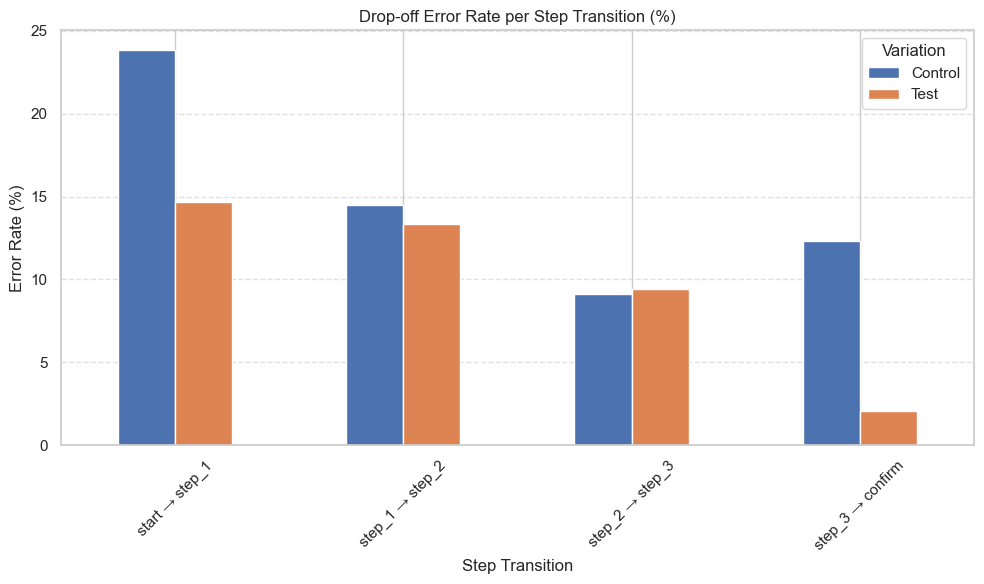

=== Drop-off Error Rate Table ===
  variation  start → step_1  step_1 → step_2  step_2 → step_3  \
0   Control           23.82            14.48             9.13   
1      Test           14.69            13.37             9.44   

   step_3 → confirm  
0             12.33  
1              2.05  


In [39]:


# === 1. Define the process steps
required_steps = ["start", "step_1", "step_2", "step_3", "confirm"]

# === 2. Clean and normalize the dataframe
df_clean = df[df["process_step"].isin(required_steps)].copy()
df_clean["process_step"] = df_clean["process_step"].str.strip().str.lower()
df_clean["date_time"] = pd.to_datetime(df_clean["date_time"], errors="coerce")

# === 3. Store drop-off counts and step reach counts
error_count_results = []
step_counts_dict = {}

for variation in ["Control", "Test"]:
    df_var = df_clean[df_clean["variation"] == variation]

    # Earliest timestamp per (visit_id, step)
    df_first = (
        df_var.sort_values(["visit_id", "process_step", "date_time"])
              .groupby(["visit_id", "process_step"], as_index=False)
              .first()
    )

    # Pivot: one row per visit
    df_wide = df_first.pivot(index="visit_id", columns="process_step", values="date_time")
    df_wide = df_wide.reindex(columns=required_steps)

    # Count how many visits reached each step
    step_counts = df_wide.notna().sum()
    step_counts_dict[variation] = step_counts.to_dict()

    # Compute drop-off counts between steps
    step_errors = {"variation": variation}
    for i in range(1, len(required_steps)):
        prev_step = required_steps[i - 1]
        curr_step = required_steps[i]

        visits_prev = step_counts[prev_step]
        visits_curr = step_counts[curr_step]

        drop_count = visits_prev - visits_curr
        step_errors[f"{prev_step} → {curr_step}"] = drop_count

    error_count_results.append(step_errors)

# === 4. Convert drop counts to DataFrame
step_error_counts_df = pd.DataFrame(error_count_results)

# === 5. Calculate drop-off rates (%)
error_rate_df = step_error_counts_df.copy()

for col in error_rate_df.columns:
    if col == "variation":
        continue
    prev_step = col.split("→")[0].strip()
    for i, row in error_rate_df.iterrows():
        variation = row["variation"]
        drop_count = row[col]
        prev_step_visits = step_counts_dict[variation][prev_step]
        drop_rate = drop_count / prev_step_visits if prev_step_visits > 0 else None
        error_rate_df.at[i, col] = float(round(drop_rate * 100, 2))

# Ensure numeric values for plotting
for col in error_rate_df.columns[1:]:
    error_rate_df[col] = error_rate_df[col].astype(float)

# === 6. Plot drop-off rates
error_rate_df_plot = error_rate_df.set_index("variation").T

error_rate_df_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Drop-off Error Rate per Step Transition (%)")
plt.ylabel("Error Rate (%)")
plt.xlabel("Step Transition")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Variation")
plt.tight_layout()
plt.show()

# === 7. Show the final table
print("=== Drop-off Error Rate Table ===")
print(error_rate_df)


In [40]:
from statsmodels.stats.proportion import proportions_ztest

# === 1. Run Z-tests for each step
print("=== Hypothesis Testing: Drop-off Rate Comparison ===")
step_tests = []

for col in step_error_counts_df.columns[1:]:  # Skip 'variation'
    step_name = col.strip()

    # Get drop counts
    drops_control = step_error_counts_df.loc[step_error_counts_df["variation"] == "Control", col].values[0]
    drops_test    = step_error_counts_df.loc[step_error_counts_df["variation"] == "Test", col].values[0]

    # Get previous step counts
    prev_step = col.split("→")[0].strip()
    n_control = step_counts_dict["Control"][prev_step]
    n_test    = step_counts_dict["Test"][prev_step]

    # Prepare data for two-proportion z-test
    counts = [drops_control, drops_test]
    nobs   = [n_control, n_test]

    # Run two-sided test (if you expect Test to improve, use `alternative='smaller'`)
    z_stat, p_val = proportions_ztest(count=counts, nobs=nobs, alternative='two-sided')

    # Save result
    step_tests.append({
        "Step": step_name,
        "Control Error Rate": round(drops_control / n_control * 100, 2),
        "Test Error Rate": round(drops_test / n_test * 100, 2),
        "Z-stat": round(z_stat, 3),
        "P-value": round(p_val, 4),
        "Significant (α=0.05)": "✅ Yes" if p_val < 0.05 else "❌ No"
    })

# === 2. Convert to DataFrame and show
ztest_df = pd.DataFrame(step_tests)
print(ztest_df)


=== Hypothesis Testing: Drop-off Rate Comparison ===
               Step  Control Error Rate  Test Error Rate  Z-stat  P-value  \
0    start → step_1               23.82            14.69  29.367   0.0000   
1   step_1 → step_2               14.48            13.37   3.644   0.0003   
2   step_2 → step_3                9.13             9.44  -1.137   0.2555   
3  step_3 → confirm               12.33             2.05  41.159   0.0000   

  Significant (α=0.05)  
0                ✅ Yes  
1                ✅ Yes  
2                 ❌ No  
3                ✅ Yes  


f:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


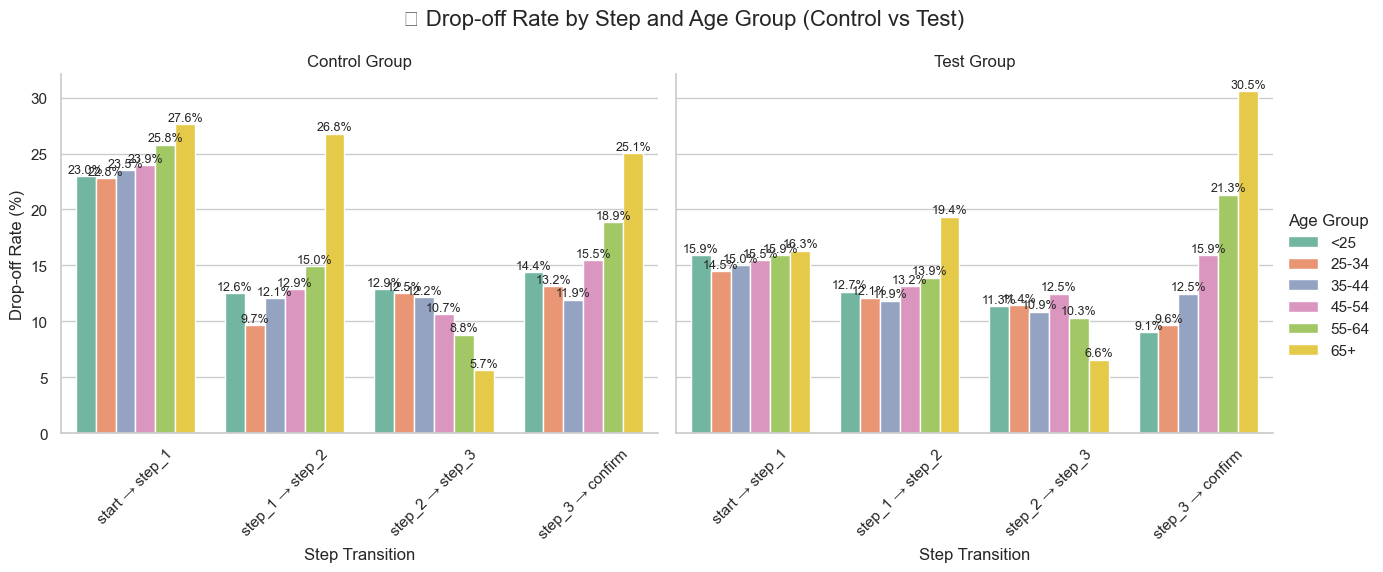


=== Chi-Squared Test Results by Step and Variation ===
               step variation    chi2  p_value significant
0    start → step_1   Control   49.83   0.0000       ✅ Yes
1    start → step_1      Test   10.34   0.0662        ❌ No
2   step_1 → step_2   Control  591.19   0.0000       ✅ Yes
3   step_1 → step_2      Test  153.90   0.0000       ✅ Yes
4   step_2 → step_3   Control  124.18   0.0000       ✅ Yes
5   step_2 → step_3      Test   89.14   0.0000       ✅ Yes
6  step_3 → confirm   Control  247.72   0.0000       ✅ Yes
7  step_3 → confirm      Test  809.62   0.0000       ✅ Yes


In [41]:


# === 1. Configuration ===
required_steps = ["start", "step_1", "step_2", "step_3", "confirm"]
step_pairs = list(zip(required_steps[:-1], required_steps[1:]))
age_bins = [0, 24, 34, 44, 54, 64, 150]
age_labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']

# Ensure age_group exists
df['age_group'] = pd.cut(df['clnt_age'], bins=age_bins, labels=age_labels)

# === 2. Clean and prepare data ===
df_clean = df[df["process_step"].isin(required_steps)].copy()
df_clean["process_step"] = df_clean["process_step"].str.strip().str.lower()
df_clean["date_time"] = pd.to_datetime(df_clean["date_time"], errors="coerce")
df_clean["age_group"] = pd.cut(df_clean["clnt_age"], bins=age_bins, labels=age_labels)

# === 3. Compute drop-off rates per step, variation, and age group ===
error_data = []

for variation in ["Control", "Test"]:
    df_var = df_clean[df_clean["variation"] == variation]
    
    df_first = (
        df_var.sort_values(["visit_id", "process_step", "date_time"])
              .groupby(["visit_id", "process_step"], as_index=False)
              .first()
    )
    
    visit_age_group = df_var[["visit_id", "age_group"]].drop_duplicates(subset="visit_id")
    df_first = df_first.merge(visit_age_group, on="visit_id", how="left")
    
    df_wide = df_first.pivot(index="visit_id", columns="process_step", values="date_time")
    df_wide = df_wide.reindex(columns=required_steps)
    df_wide["age_group"] = visit_age_group.set_index("visit_id").reindex(df_wide.index)["age_group"]

    for step_from, step_to in step_pairs:
        for age_group in age_labels:
            mask = df_wide["age_group"] == age_group
            n_from = df_wide.loc[mask, step_from].notna().sum()
            n_to = df_wide.loc[mask, step_from].notna() & df_wide.loc[mask, step_to].notna()
            n_to = n_to.sum()
            drop = max(n_from - n_to, 0)
            rate = (drop / n_from * 100) if n_from > 0 else 0
            error_data.append({
                "step": f"{step_from} → {step_to}",
                "variation": variation,
                "age_group": age_group,
                "n_from": n_from,
                "n_to": n_to,
                "errors": drop,
                "drop_rate": round(rate, 2)
            })

error_df = pd.DataFrame(error_data)

# === 4. Plot: Drop-off rate by step and age group ===
sns.set(style="whitegrid")

g = sns.catplot(
    data=error_df,
    x="step", y="drop_rate", hue="age_group",
    col="variation",
    kind="bar",
    height=5, aspect=1.3,
    palette="Set2",
    legend_out=True
)

for ax in g.axes.flatten():
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", label_type="edge", fontsize=9)

g.set_axis_labels("Step Transition", "Drop-off Rate (%)")
g.set_titles("{col_name} Group")
g.set_xticklabels(rotation=45)
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("🔍 Drop-off Rate by Step and Age Group (Control vs Test)", fontsize=16)
g._legend.set_title("Age Group")
plt.show()

# === 5. Chi-squared test per step & variation ===
from scipy.stats import chi2_contingency

chi_results = []

for step in error_df["step"].unique():
    for variation in ["Control", "Test"]:
        df_sub = error_df[(error_df["step"] == step) & (error_df["variation"] == variation)]
        if df_sub.empty or df_sub.shape[0] < 2:
            continue
        observed = df_sub[["errors", "n_to"]].fillna(0).astype(int).values
        if observed.shape[0] > 1 and (observed >= 0).all():
            chi2, p, _, _ = chi2_contingency(observed)
            chi_results.append({
                "step": step,
                "variation": variation,
                "chi2": round(chi2, 2),
                "p_value": round(p, 4),
                "significant": "✅ Yes" if p < 0.05 else "❌ No"
            })

chi_df = pd.DataFrame(chi_results)

# === 6. Show statistical test result ===
print("\n=== Chi-Squared Test Results by Step and Variation ===")
print(chi_df)


C:\Users\jorgi\AppData\Local\Temp\ipykernel_2760\135377206.py:74: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
f:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


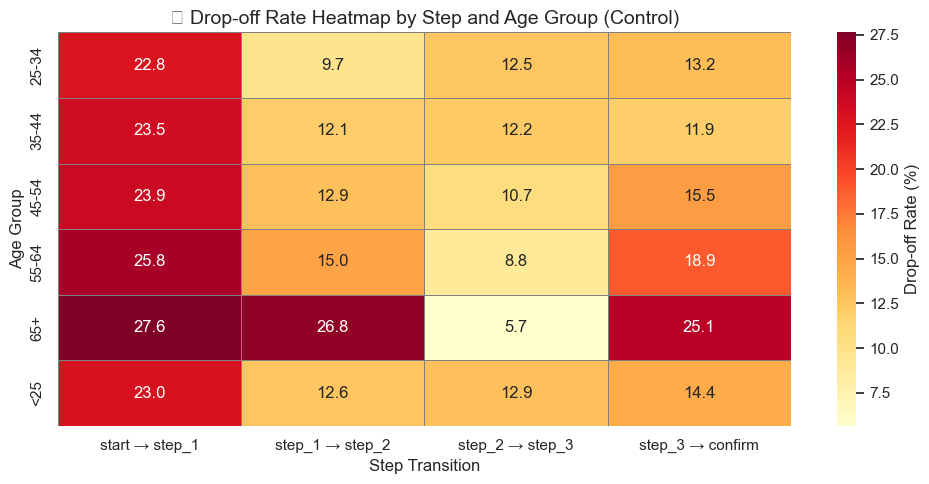

C:\Users\jorgi\AppData\Local\Temp\ipykernel_2760\135377206.py:74: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
f:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


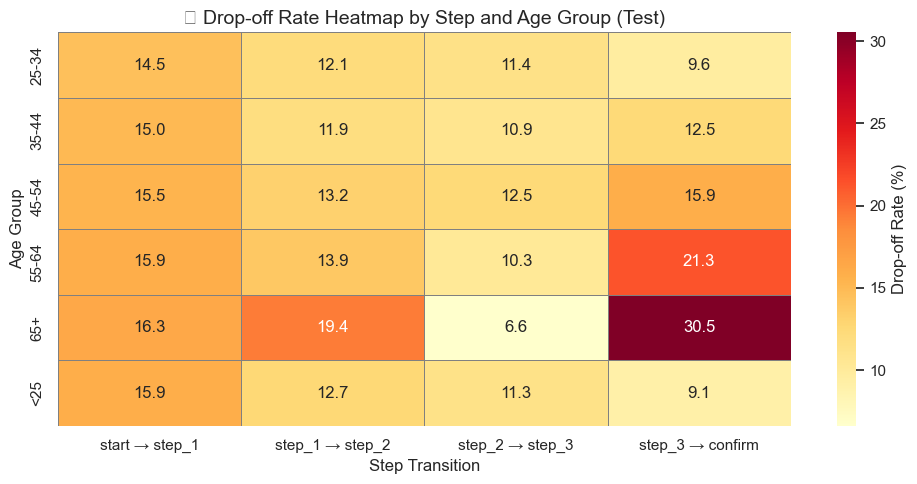


=== Chi-Squared Test Results by Step and Variation ===
               step variation    chi2  p_value significant
0    start → step_1   Control   49.83   0.0000       ✅ Yes
1    start → step_1      Test   10.34   0.0662        ❌ No
2   step_1 → step_2   Control  591.19   0.0000       ✅ Yes
3   step_1 → step_2      Test  153.90   0.0000       ✅ Yes
4   step_2 → step_3   Control  124.18   0.0000       ✅ Yes
5   step_2 → step_3      Test   89.14   0.0000       ✅ Yes
6  step_3 → confirm   Control  247.72   0.0000       ✅ Yes
7  step_3 → confirm      Test  809.62   0.0000       ✅ Yes


In [42]:

# === 1. Configuration ===
required_steps = ["start", "step_1", "step_2", "step_3", "confirm"]
step_pairs = list(zip(required_steps[:-1], required_steps[1:]))
age_bins = [0, 24, 34, 44, 54, 64, 150]
age_labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']

# Create age_group
df['age_group'] = pd.cut(df['clnt_age'], bins=age_bins, labels=age_labels)

# === 2. Clean data ===
df_clean = df[df["process_step"].isin(required_steps)].copy()
df_clean["process_step"] = df_clean["process_step"].str.strip().str.lower()
df_clean["date_time"] = pd.to_datetime(df_clean["date_time"], errors="coerce")
df_clean["age_group"] = pd.cut(df_clean["clnt_age"], bins=age_bins, labels=age_labels)

# === 3. Compute drop-off rates per step, variation, and age group ===
error_data = []

for variation in ["Control", "Test"]:
    df_var = df_clean[df_clean["variation"] == variation]

    df_first = (
        df_var.sort_values(["visit_id", "process_step", "date_time"])
              .groupby(["visit_id", "process_step"], as_index=False)
              .first()
    )

    visit_age_group = df_var[["visit_id", "age_group"]].drop_duplicates(subset="visit_id")
    df_first = df_first.merge(visit_age_group, on="visit_id", how="left")

    df_wide = df_first.pivot(index="visit_id", columns="process_step", values="date_time")
    df_wide = df_wide.reindex(columns=required_steps)
    df_wide["age_group"] = visit_age_group.set_index("visit_id").reindex(df_wide.index)["age_group"]

    for step_from, step_to in step_pairs:
        for age_group in age_labels:
            mask = df_wide["age_group"] == age_group
            n_from = df_wide.loc[mask, step_from].notna().sum()
            n_to = df_wide.loc[mask, step_from].notna() & df_wide.loc[mask, step_to].notna()
            n_to = n_to.sum()
            drop = max(n_from - n_to, 0)
            rate = (drop / n_from * 100) if n_from > 0 else 0
            error_data.append({
                "variation": variation,
                "step": f"{step_from} → {step_to}",
                "age_group": age_group,
                "drop_rate": round(rate, 2),
                "n_from": n_from,
                "n_to": n_to,
                "errors": drop
            })

error_df = pd.DataFrame(error_data)

# === 4. Plot Heatmaps ===
for variation in ["Control", "Test"]:
    pivot_df = error_df[error_df["variation"] == variation].pivot(
        index="age_group", columns="step", values="drop_rate"
    )

    plt.figure(figsize=(10, 5))
    sns.heatmap(
        pivot_df,
        annot=True,
        fmt=".1f",
        cmap="YlOrRd",
        linewidths=0.5,
        linecolor='gray',
        cbar_kws={"label": "Drop-off Rate (%)"}
    )
    plt.title(f"🔥 Drop-off Rate Heatmap by Step and Age Group ({variation})", fontsize=14)
    plt.ylabel("Age Group")
    plt.xlabel("Step Transition")
    plt.tight_layout()
    plt.show()

# === 5. Optional: Chi-Squared Test by Step and Variation ===
chi_results = []
for step in error_df["step"].unique():
    for variation in ["Control", "Test"]:
        df_sub = error_df[(error_df["step"] == step) & (error_df["variation"] == variation)]
        if df_sub.empty or df_sub.shape[0] < 2:
            continue
        observed = df_sub[["errors", "n_to"]].fillna(0).astype(int).values
        if observed.shape[0] > 1 and (observed >= 0).all():
            chi2, p, _, _ = chi2_contingency(observed)
            chi_results.append({
                "step": step,
                "variation": variation,
                "chi2": round(chi2, 2),
                "p_value": round(p, 4),
                "significant": "✅ Yes" if p < 0.05 else "❌ No"
            })

chi_df = pd.DataFrame(chi_results)
print("\n=== Chi-Squared Test Results by Step and Variation ===")
print(chi_df)


In [55]:
stepbacks_per_user = df_stepbacks.groupby(["variation", "visit_id"]).size().reset_index(name="step_back_count")

In [80]:
control_errors = stepbacks_per_user[stepbacks_per_user["variation"] == "Control"]["step_back_count"]
test_errors = stepbacks_per_user[stepbacks_per_user["variation"] == "Test"]["step_back_count"]

# Perform Welch's t-test (assumes unequal variances)
t_stat, p_val = ttest_ind(control_errors, test_errors, equal_var=False)

print("=== T-Test: Avg. Step-Backs per User ===")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")
print("Significant?" , "✅ Yes" if p_val < 0.05 else "❌ No")

=== T-Test: Avg. Step-Backs per User ===
T-statistic: -9.9537
P-value: 0.0000
Significant? ✅ Yes


In [69]:
stepbacks_per_user

,variation,visit_id,step_back_count
0,Control,100037962_47432393712_705583,1
1,Control,100057941_88477660212_944512,1
2,Control,10006594_66157970412_679648,1
3,Control,100195539_90558871716_822894,1
4,Control,10045388_98429038488_557266,1
...,...,...,...
16664,Test,999745626_63135446754_695326,3
16665,Test,999759701_27012733172_594750,1
16666,Test,999890686_31377985689_29808,1
16667,Test,999960019_60838685252_926860,2


C:\Users\jorgi\AppData\Local\Temp\ipykernel_2760\1474971061.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=stepbacks_per_user, x="variation", y="step_back_count", palette="Set2")


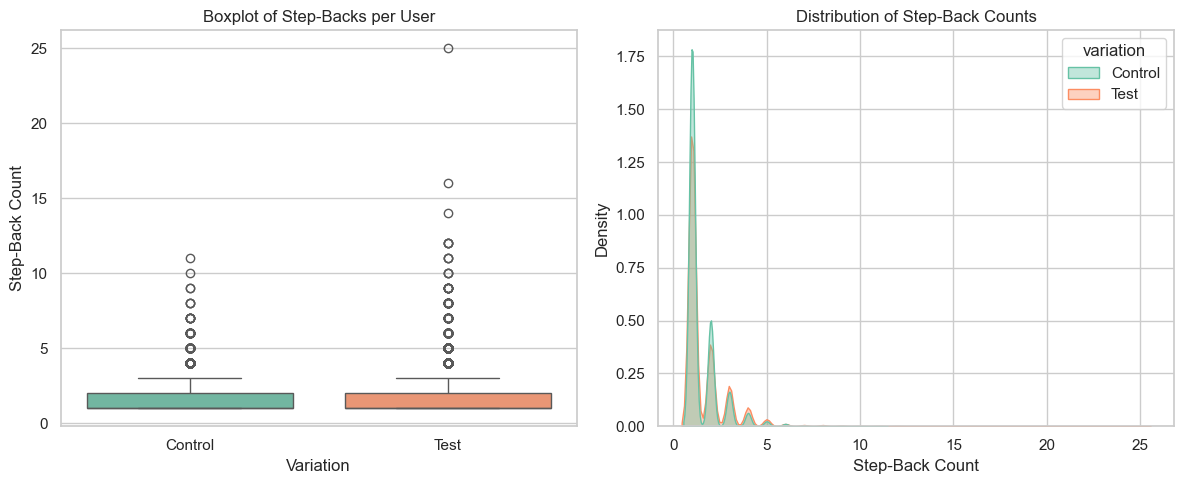

In [59]:
# Assuming `stepbacks_per_user` contains 'variation' and 'step_back_count'

plt.figure(figsize=(12, 5))

# --- 1. Boxplot ---
plt.subplot(1, 2, 1)
sns.boxplot(data=stepbacks_per_user, x="variation", y="step_back_count", palette="Set2")
plt.title("Boxplot of Step-Backs per User")
plt.xlabel("Variation")
plt.ylabel("Step-Back Count")

# --- 2. Distribution Plot ---
plt.subplot(1, 2, 2)
sns.kdeplot(
    data=stepbacks_per_user,
    x="step_back_count",
    hue="variation",
    common_norm=False,
    fill=True,
    palette="Set2",
    alpha=0.4
)
plt.title("Distribution of Step-Back Counts")
plt.xlabel("Step-Back Count")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

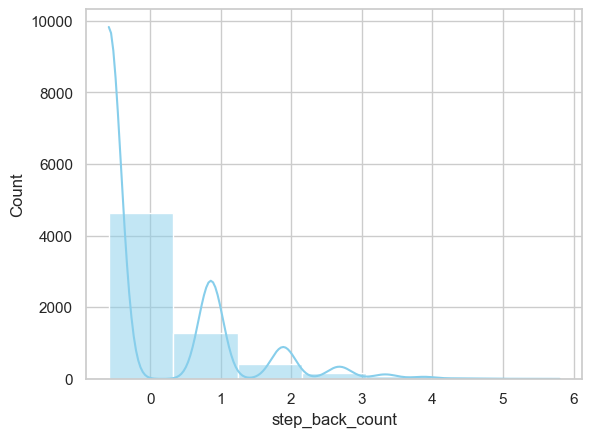

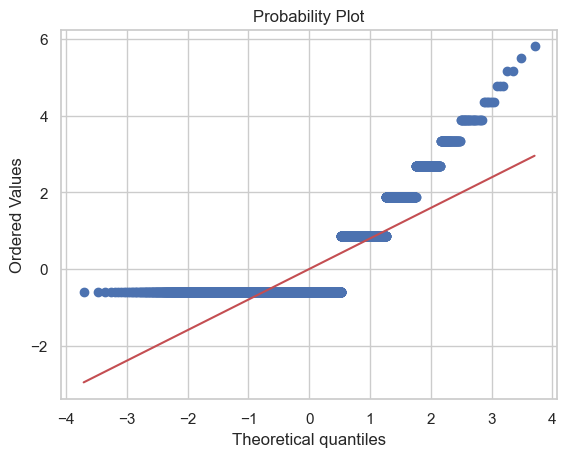

In [75]:
from scipy import stats
log_transformed_control = np.log1p(stepbacks_per_user['step_back_count'][stepbacks_per_user['variation'] == 'Control'])
standardized_log_control = (log_transformed_control - log_transformed_control.mean()) / log_transformed_control.std()
sns.histplot(standardized_log_control, kde=True, bins=7, color="skyblue")
plt.show()

stats.probplot(standardized_log_control, plot=plt);
plt.show()

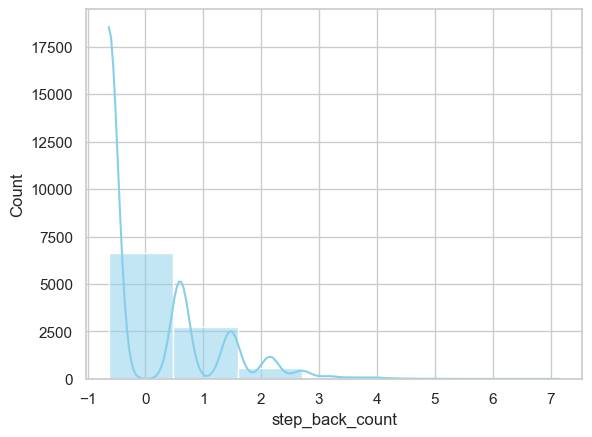

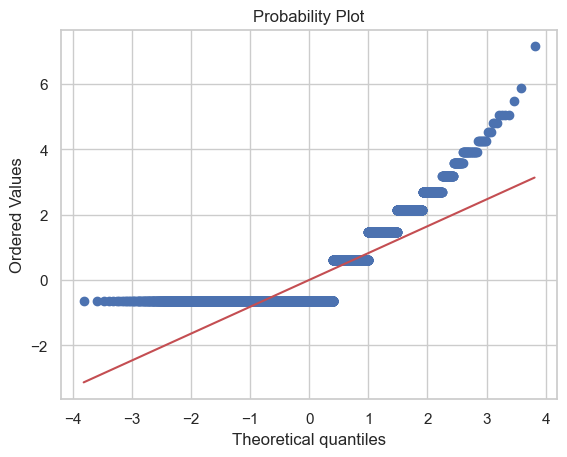

In [76]:
from scipy import stats
log_transformed_test = np.log1p(stepbacks_per_user['step_back_count'][stepbacks_per_user['variation'] == 'Test'])
standardized_log_test = (log_transformed_test - log_transformed_test.mean()) / log_transformed_test.std()
sns.histplot(standardized_log_test, kde=True, bins=7, color="skyblue")
plt.show()

stats.probplot(standardized_log_test, plot=plt);
plt.show()

=== Step-Back Events per Variation ===
  variation  step_back_events
0      Test             16352
1   Control              9730

=== Step-Back Users Summary ===
  variation  users_with_stepbacks  avg_stepbacks_per_user
0   Control                  6626                1.468458
1      Test                 10043                1.628199


C:\Users\jorgi\AppData\Local\Temp\ipykernel_2760\193196311.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stepback_counts, x="variation", y="step_back_events", palette="pastel")


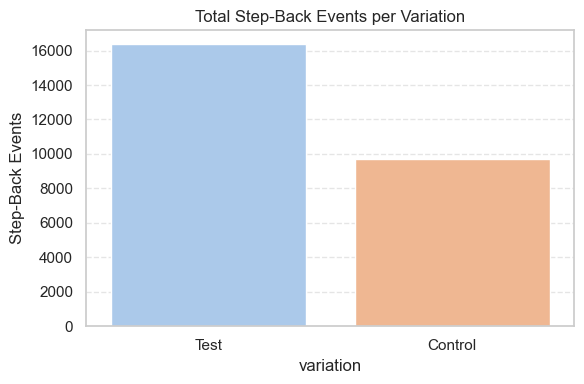


=== Chi-Squared Test: Step-Backs by Variation ===
Chi2 Statistic: 619.3366
P-value: 0.0000
Statistically Significant? ✅ Yes


C:\Users\jorgi\AppData\Local\Temp\ipykernel_2760\193196311.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat_data = df_var.groupby(["age_group", "transition"]).size().unstack(fill_value=0)
C:\Users\jorgi\AppData\Local\Temp\ipykernel_2760\193196311.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat_data = df_var.groupby(["age_group", "transition"]).size().unstack(fill_value=0)


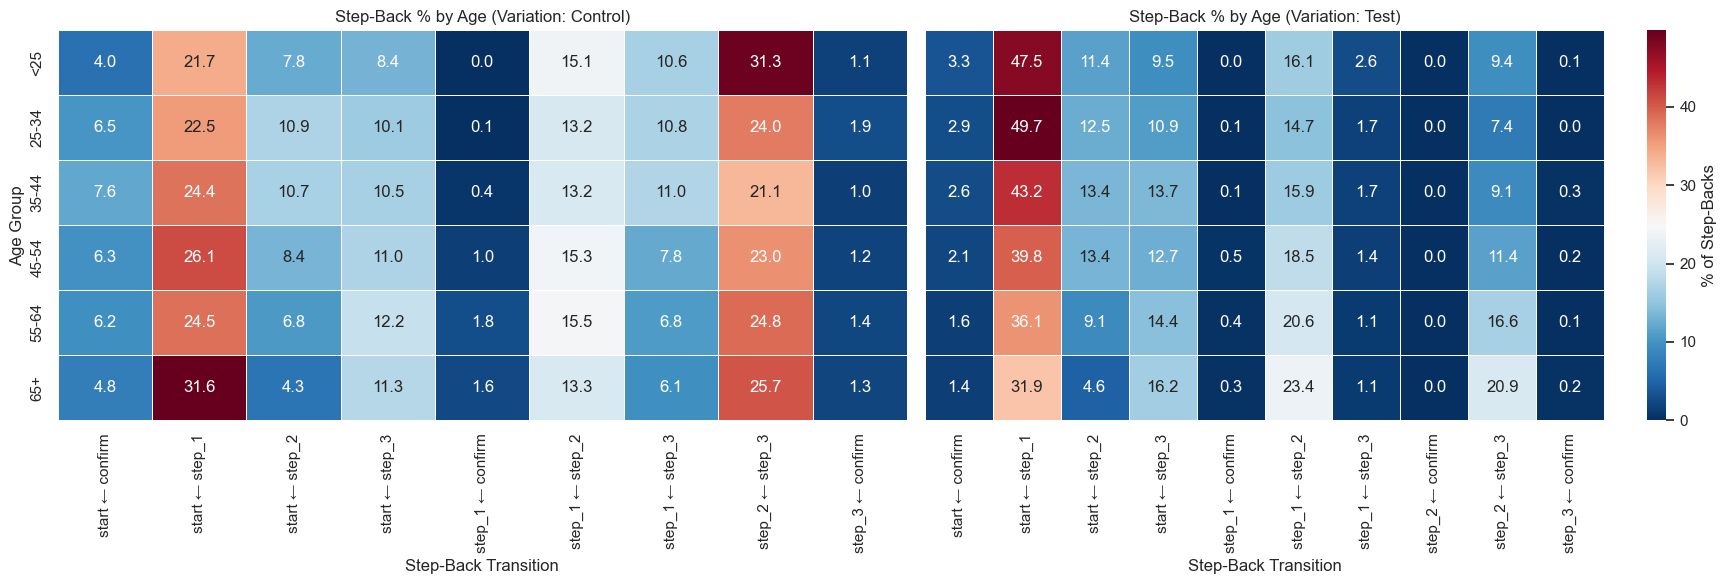

In [44]:
# === 1. Setup ===
required_steps = ["start", "step_1", "step_2", "step_3", "confirm"]
step_order = {step: i for i, step in enumerate(required_steps)}
age_bins = [0, 24, 34, 44, 54, 64, 150]
age_labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
df["age_group"] = pd.cut(df["clnt_age"], bins=age_bins, labels=age_labels)

# === 2. Sort per visit by time, detect step-backs ===
df_sorted = df[df["process_step"].isin(required_steps)].copy()
df_sorted["step_index"] = df_sorted["process_step"].map(step_order)
df_sorted = df_sorted.sort_values(["visit_id", "date_time"])
df_sorted["prev_step_index"] = df_sorted.groupby("visit_id")["step_index"].shift(1)
df_sorted["prev_step"] = df_sorted.groupby("visit_id")["process_step"].shift(1)
df_sorted["step_back"] = df_sorted["step_index"] < df_sorted["prev_step_index"]

# === 3. Filter to actual step-backs ===
df_stepbacks = df_sorted[df_sorted["step_back"] == True].copy()
df_stepbacks["transition"] = df_stepbacks["process_step"] + " ← " + df_stepbacks["prev_step"]

# === 4. Count of step-backs per variation ===
stepback_counts = df_stepbacks["variation"].value_counts().reset_index()
stepback_counts.columns = ["variation", "step_back_events"]
print("=== Step-Back Events per Variation ===")
print(stepback_counts)

# === 5. Users with step-backs and their avg count ===
per_user = df_stepbacks.groupby(["variation", "visit_id"]).size().reset_index(name="step_backs_per_user")
user_summary = per_user.groupby("variation")["step_backs_per_user"].agg(["count", "mean"]).reset_index()
user_summary.columns = ["variation", "users_with_stepbacks", "avg_stepbacks_per_user"]
print("\n=== Step-Back Users Summary ===")
print(user_summary)

# === 6. Bar Plot: Step-Back Events per Variation ===
plt.figure(figsize=(6, 4))
sns.barplot(data=stepback_counts, x="variation", y="step_back_events", palette="pastel")
plt.title("Total Step-Back Events per Variation")
plt.ylabel("Step-Back Events")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# === 7. Chi-squared Test between variations ===
stepback_table = pd.crosstab(df_sorted["variation"], df_sorted["step_back"])
chi2, p, _, _ = chi2_contingency(stepback_table)
print(f"\n=== Chi-Squared Test: Step-Backs by Variation ===")
print(f"Chi2 Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print("Statistically Significant?" , "✅ Yes" if p < 0.05 else "❌ No")

# === 8. Split heatmaps by variation ===
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for i, variation in enumerate(["Control", "Test"]):
    df_var = df_stepbacks[df_stepbacks["variation"] == variation]
    heat_data = df_var.groupby(["age_group", "transition"]).size().unstack(fill_value=0)
    heatmap_pct = heat_data.div(heat_data.sum(axis=1), axis=0) * 100

    sns.heatmap(heatmap_pct, annot=True, fmt=".1f", cmap="RdBu_r", linewidths=0.5,
                cbar=i==1, ax=axes[i], cbar_kws={"label": "% of Step-Backs"} if i==1 else None)

    axes[i].set_title(f"Step-Back % by Age (Variation: {variation})")
    axes[i].set_xlabel("Step-Back Transition")
    axes[i].set_ylabel("Age Group" if i == 0 else "")

plt.tight_layout()
plt.show()

=== Step-Back Events per Variation ===
  variation  step_back_events
0      Test             16352
1   Control              9730

=== Step-Back Users Summary ===
  variation  users_with_stepbacks  avg_stepbacks_per_user
0   Control                  6626                1.468458
1      Test                 10043                1.628199


C:\Users\jorgi\AppData\Local\Temp\ipykernel_2760\3642799323.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stepback_counts, x="variation", y="step_back_events", palette="pastel")


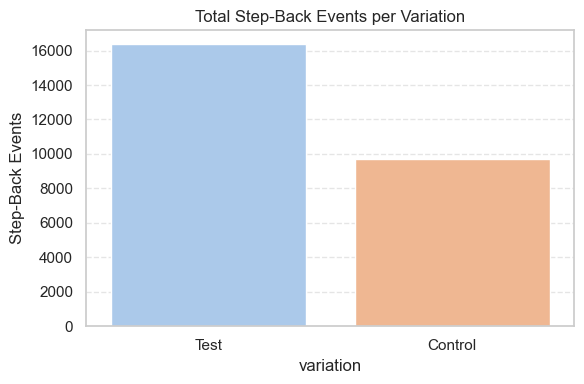


=== Chi-Squared Test: Step-Backs by Variation ===
Chi2 Statistic: 619.3366
P-value: 0.0000
Statistically Significant? ✅ Yes


C:\Users\jorgi\AppData\Local\Temp\ipykernel_2760\3642799323.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_stepbacks_valid.groupby(["variation", "age_group", "transition"]).size().reset_index(name="count")
C:\Users\jorgi\AppData\Local\Temp\ipykernel_2760\3642799323.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped["pct"] = grouped.groupby(["variation", "age_group"])["count"].transform(lambda x: x / x.sum() * 100)


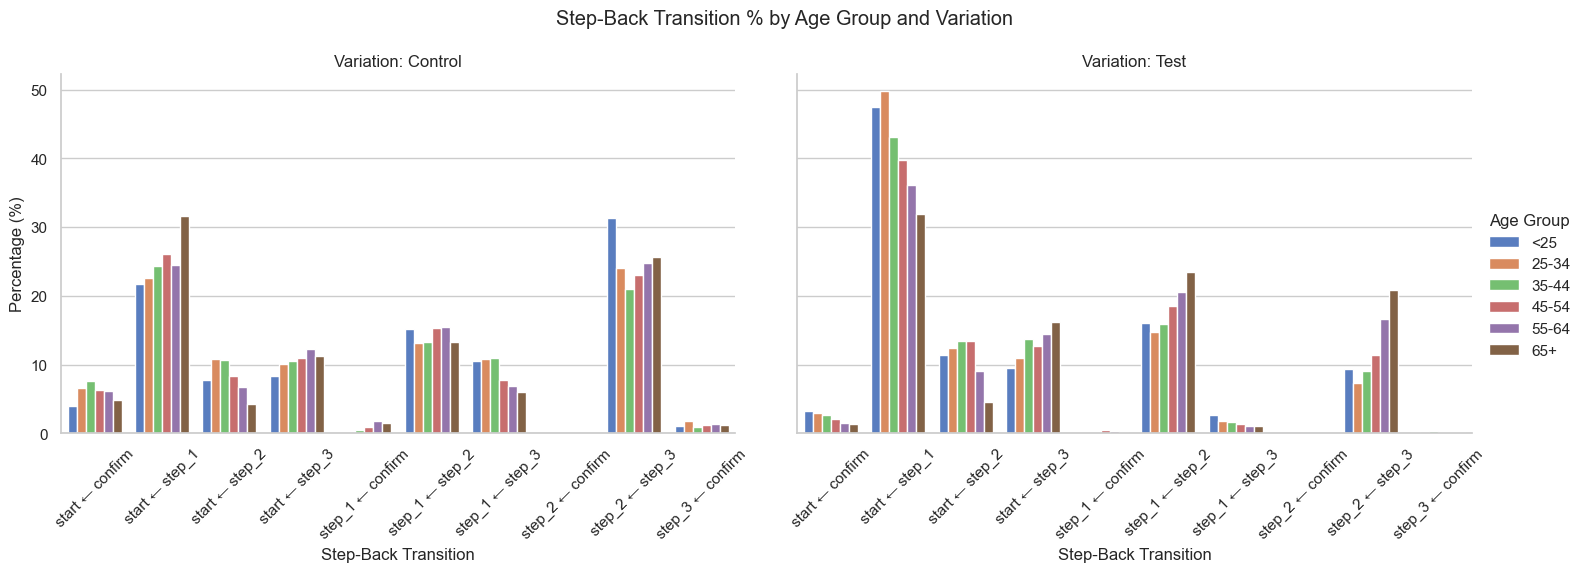

In [45]:
# === 1. Setup ===
required_steps = ["start", "step_1", "step_2", "step_3", "confirm"]
step_order = {step: i for i, step in enumerate(required_steps)}
age_bins = [0, 24, 34, 44, 54, 64, 150]
age_labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
df["age_group"] = pd.cut(df["clnt_age"], bins=age_bins, labels=age_labels)

# === 2. Sort per visit by time, detect step-backs ===
df_sorted = df[df["process_step"].isin(required_steps)].copy()
df_sorted["step_index"] = df_sorted["process_step"].map(step_order)
df_sorted = df_sorted.sort_values(["visit_id", "date_time"])
df_sorted["prev_step_index"] = df_sorted.groupby("visit_id")["step_index"].shift(1)
df_sorted["prev_step"] = df_sorted.groupby("visit_id")["process_step"].shift(1)
df_sorted["step_back"] = df_sorted["step_index"] < df_sorted["prev_step_index"]

# === 3. Filter to actual step-backs ===
df_stepbacks = df_sorted[df_sorted["step_back"] == True].copy()
df_stepbacks["transition"] = df_stepbacks["process_step"] + " ← " + df_stepbacks["prev_step"]

# === 4. Count of step-backs per variation ===
stepback_counts = df_stepbacks["variation"].value_counts().reset_index()
stepback_counts.columns = ["variation", "step_back_events"]
print("=== Step-Back Events per Variation ===")
print(stepback_counts)

# === 5. Users with step-backs and their avg count ===
per_user = df_stepbacks.groupby(["variation", "visit_id"]).size().reset_index(name="step_backs_per_user")
user_summary = per_user.groupby("variation")["step_backs_per_user"].agg(["count", "mean"]).reset_index()
user_summary.columns = ["variation", "users_with_stepbacks", "avg_stepbacks_per_user"]
print("\n=== Step-Back Users Summary ===")
print(user_summary)

# === 6. Bar Plot: Step-Back Events per Variation ===
plt.figure(figsize=(6, 4))
sns.barplot(data=stepback_counts, x="variation", y="step_back_events", palette="pastel")
plt.title("Total Step-Back Events per Variation")
plt.ylabel("Step-Back Events")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# === 7. Chi-squared Test between variations ===
stepback_table = pd.crosstab(df_sorted["variation"], df_sorted["step_back"])
chi2, p, _, _ = chi2_contingency(stepback_table)
print(f"\n=== Chi-Squared Test: Step-Backs by Variation ===")
print(f"Chi2 Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print("Statistically Significant?" , "✅ Yes" if p < 0.05 else "❌ No")
# === 8. Catplot: Step-Back Rate by Age Group and Transition, Split by Variation ===

# Rebuild step-back percentage data
df_stepbacks_valid = df_stepbacks.dropna(subset=["transition", "age_group"])

# Count transitions per age group and variation
grouped = df_stepbacks_valid.groupby(["variation", "age_group", "transition"]).size().reset_index(name="count")

# Normalize per age_group within each variation to get %
grouped["pct"] = grouped.groupby(["variation", "age_group"])["count"].transform(lambda x: x / x.sum() * 100)

# Plot using catplot (faceted bar chart)
g = sns.catplot(
    data=grouped,
    kind="bar",
    x="transition",
    y="pct",
    hue="age_group",
    col="variation",
    palette="muted",
    height=5,
    aspect=1.5
)

g.set_titles("Variation: {col_name}")
g.set_axis_labels("Step-Back Transition", "Percentage (%)")
g.set_xticklabels(rotation=45)
g._legend.set_title("Age Group")
plt.subplots_adjust(top=0.85)
g.fig.suptitle("Step-Back Transition % by Age Group and Variation")
plt.show()

In [46]:
# Step-back transitions to test
transitions = df_stepbacks["transition"].unique()
test_results = []

for trans in transitions:
    control_count = df_stepbacks[(df_stepbacks["transition"] == trans) & (df_stepbacks["variation"] == "Control")].shape[0]
    test_count = df_stepbacks[(df_stepbacks["transition"] == trans) & (df_stepbacks["variation"] == "Test")].shape[0]
    
    control_other = df_stepbacks[(df_stepbacks["transition"] != trans) & (df_stepbacks["variation"] == "Control")].shape[0]
    test_other = df_stepbacks[(df_stepbacks["transition"] != trans) & (df_stepbacks["variation"] == "Test")].shape[0]
    
    contingency = np.array([[control_count, control_other],
                            [test_count, test_other]])
    
    chi2, p, _, _ = chi2_contingency(contingency)
    
    test_results.append({
        "transition": trans,
        "Control": control_count,
        "Test": test_count,
        "chi2": round(chi2, 2),
        "p_value": round(p, 4),
        "significant": "✅ Yes" if p < 0.05 else "❌ No"
    })

chi_step_df = pd.DataFrame(test_results).sort_values("p_value")
print("\n=== Chi-Squared Tests per Step-Back Transition ===")
print(chi_step_df)


=== Chi-Squared Tests per Step-Back Transition ===
         transition  Control  Test    chi2  p_value significant
0   step_1 ← step_2     1391  3143  102.68      0.0       ✅ Yes
1    start ← step_1     2494  6408  498.01      0.0       ✅ Yes
2   step_1 ← step_3      815   227  774.82      0.0       ✅ Yes
3  step_3 ← confirm      130    29  133.27      0.0       ✅ Yes
4   step_2 ← step_3     2367  2287  444.26      0.0       ✅ Yes
5   start ← confirm      592   334  289.83      0.0       ✅ Yes
6    start ← step_3     1068  2236   39.89      0.0       ✅ Yes
7    start ← step_2      775  1641   30.87      0.0       ✅ Yes
8  step_1 ← confirm       98    46   57.23      0.0       ✅ Yes
9  step_2 ← confirm        0     1    0.00      1.0        ❌ No


C:\Users\jorgi\AppData\Local\Temp\ipykernel_2760\371327349.py:26: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
f:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


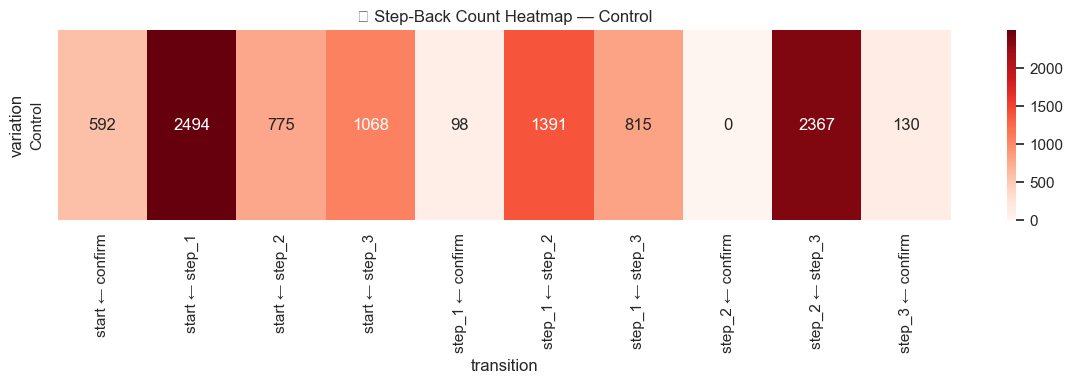

C:\Users\jorgi\AppData\Local\Temp\ipykernel_2760\371327349.py:32: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
f:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


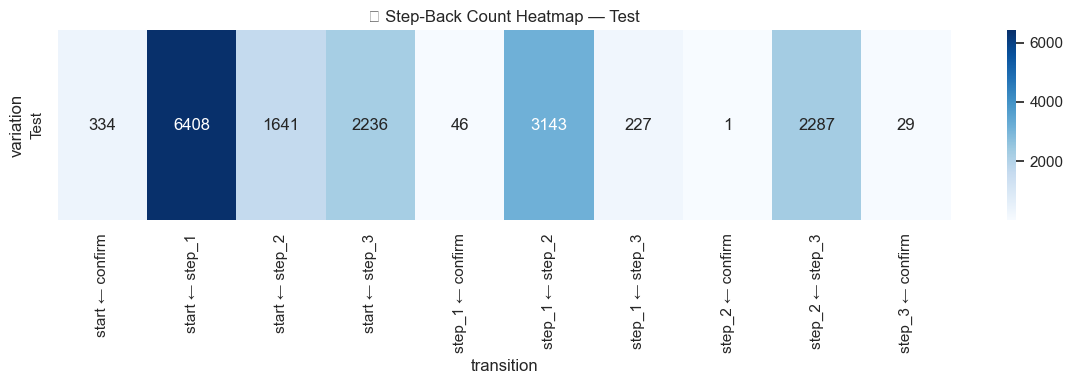

C:\Users\jorgi\AppData\Local\Temp\ipykernel_2760\371327349.py:42: UserWarning: Glyph 128258 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS WITH CIRCLED ONE OVERLAY}) missing from font(s) Arial.
  plt.tight_layout()
f:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128258 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS WITH CIRCLED ONE OVERLAY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


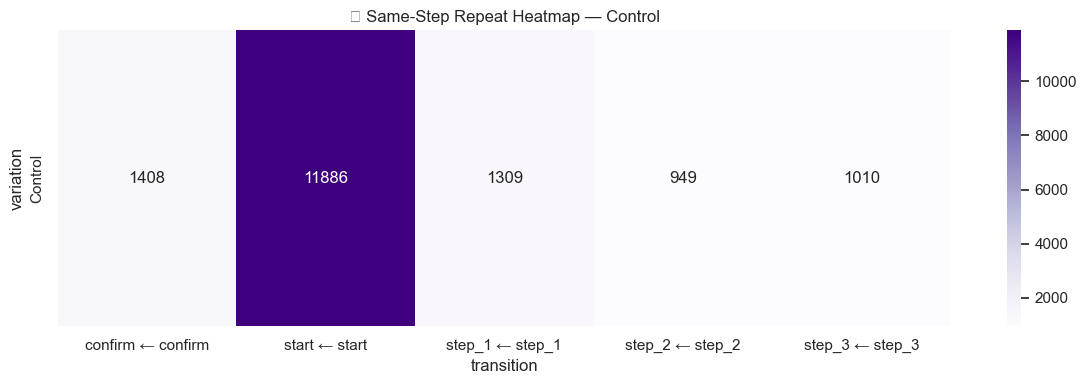

C:\Users\jorgi\AppData\Local\Temp\ipykernel_2760\371327349.py:48: UserWarning: Glyph 128258 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS WITH CIRCLED ONE OVERLAY}) missing from font(s) Arial.
  plt.tight_layout()
f:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128258 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS WITH CIRCLED ONE OVERLAY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


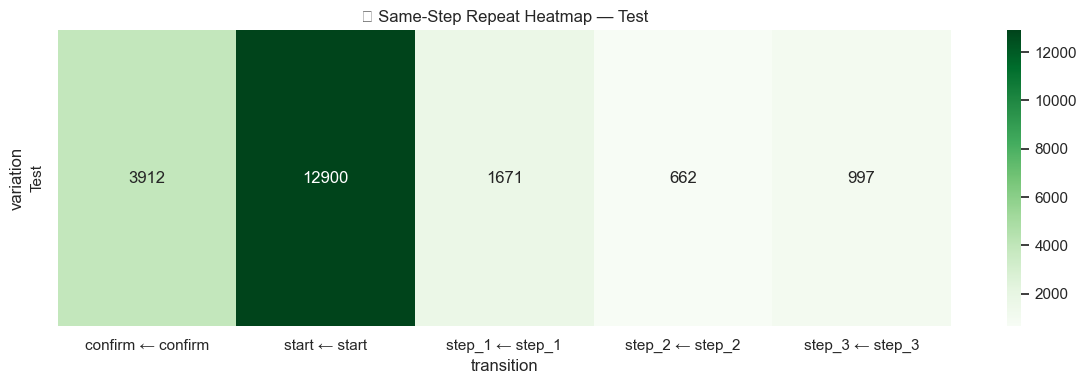

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['index']"

In [47]:
# === 2. Setup ===
required_steps = ["start", "step_1", "step_2", "step_3", "confirm"]
step_order = {step: i for i, step in enumerate(required_steps)}

# === 3. Prepare data ===
df = df[df["process_step"].isin(required_steps)].copy()
df["step_index"] = df["process_step"].map(step_order)
df = df.sort_values(["visit_id", "date_time"])

# Shift step_index and step for comparison
df["prev_step_index"] = df.groupby("visit_id")["step_index"].shift(1)
df["prev_step"] = df.groupby("visit_id")["process_step"].shift(1)

# Detect anomalies
df["step_back"] = df["step_index"] < df["prev_step_index"]
df["step_same"] = df["step_index"] == df["prev_step_index"]
df["transition"] = df["process_step"] + " ← " + df["prev_step"]

# === 4. Step-back heatmap ===
df_stepback = df[df["step_back"]]
heat_stepback = df_stepback.groupby(["variation", "transition"]).size().unstack().fillna(0)

plt.figure(figsize=(12, 4))
sns.heatmap(heat_stepback.loc[["Control"]], annot=True, fmt=".0f", cmap="Reds")
plt.title("🔁 Step-Back Count Heatmap — Control")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
sns.heatmap(heat_stepback.loc[["Test"]], annot=True, fmt=".0f", cmap="Blues")
plt.title("🔁 Step-Back Count Heatmap — Test")
plt.tight_layout()
plt.show()

# === 5. Same-step heatmap ===
df_samestep = df[df["step_same"]]
heat_samestep = df_samestep.groupby(["variation", "transition"]).size().unstack().fillna(0)

plt.figure(figsize=(12, 4))
sns.heatmap(heat_samestep.loc[["Control"]], annot=True, fmt=".0f", cmap="Purples")
plt.title("🔂 Same-Step Repeat Heatmap — Control")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
sns.heatmap(heat_samestep.loc[["Test"]], annot=True, fmt=".0f", cmap="Greens")
plt.title("🔂 Same-Step Repeat Heatmap — Test")
plt.tight_layout()
plt.show()

# === 6. Grouped Bar Chart — Step-back & Same-step ===
error_counts = pd.DataFrame({
    "step_back": df_stepback["variation"].value_counts(),
    "step_same": df_samestep["variation"].value_counts()
}).reset_index().melt(id_vars="index", var_name="error_type", value_name="count")

plt.figure(figsize=(8, 5))
sns.barplot(data=error_counts, x="error_type", y="count", hue="index")
plt.title("🔁 Step-back vs 🔂 Same-step Errors by Variation")
plt.ylabel("Event Count")
plt.xlabel("Error Type")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# === 7. Chi-squared test ===
step_back_counts = df_stepback["variation"].value_counts()
same_step_counts = df_samestep["variation"].value_counts()

contingency = pd.DataFrame({
    "Step Back": step_back_counts,
    "Same Step": same_step_counts
}).fillna(0).astype(int)

chi2, p, _, _ = chi2_contingency(contingency.T)
print("\n=== Chi-Squared Test for Error Type vs Variation ===")
print("Chi-squared:", round(chi2, 2))
print("p-value:", round(p, 4))
print("Statistically significant? ", "✅ Yes" if p < 0.05 else "❌ No")

In [ ]:
🔴 Strong positive values (Test >> Control)

<25 and 25–34 show +25 to +27 pp for start ← step_1.
👉 Younger Test users go back from step_1 to start far more frequently than Control.

For 65+, there’s +10 pp in step_1 ← step_2.
👉 Older Test users more often bounce back from step_2 to step_1.

🔵 Strong negative values (Control >> Test)

Across all age groups, Test is 15–22 pp lower in step_2 ← step_3.
👉 Control users more frequently step back from step_3 to step_2.

Also, in younger groups, Test does fewer step_1 ← step_3 (–7 to –9 pp).

⚖️ Neutral or small values

Transitions like step_3 ← confirm or step_1 ← confirm are very close to 0.
👉 Both variations behave similarly when going back from the end.

In [ ]:
🔴 Where Test dominates ( >70% )

Start ← step_1: Across all ages, ~70–75% of these step-backs come from Test.
👉 Test users are much more likely to restart the funnel after step_1.

Start ← step_2: Older groups (55–64, 65+) ~71–78% are Test.
👉 Test users (especially older) step back further after step_2.

Start ← step_3 and Start ← confirm: consistently >60% Test.
👉 Test users more often reset earlier steps after being deeper in the funnel.

🔵 Where Control dominates (<50%)

Step_2 ← step_3: only ~18–26% are Test (so ~75–80% are Control).
👉 Control users frequently step back from step_3 to step_2.

Step_3 ← confirm: nearly always 0% Test (so these events are almost exclusively Control).
👉 Control users sometimes undo confirmation, Test almost never.

⚖️ Mixed / balanced

Step_1 ← step_3: ~25–30% Test → mostly Control, but not extreme.

Step_1 ← confirm: varies (25–50%), more balanced, but often leaning Control.